In [3]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pd.read_csv("vietnam_housing_dataset.csv")

# Xử lý địa chỉ: Lấy tỉnh/thành phố (phần tử cuối cùng của Address)
df["Province"] = df["Address"].apply(lambda x: str(x).split(",")[-1].strip())

# Loại bỏ các đặc trưng gây nhiễu/quá nhiều null (>70%) và cột Address thô
drop_cols = ["Address", "House direction", "Balcony direction"]
df_clean = df.drop(columns=drop_cols)

# Xác định Features (X) và Target (y)
X = df_clean.drop(columns=["Price"])
y = df_clean["Price"]

num_cols = ["Area", "Frontage", "Access Road", "Floors", "Bedrooms", "Bathrooms"]
cat_cols = ["Legal status", "Furniture state", "Province"]

# Pipeline xử lý dữ liệu: Impute + Scale cho số, Impute + OneHot cho chuỗi
num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols),
    ]
)

# Chia tập Train/Test (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(
    f"Dữ liệu huấn luyện: {X_train.shape[0]} mẫu, Dữ liệu kiểm tra: {X_test.shape[0]} mẫu"
)

Dữ liệu huấn luyện: 24183 mẫu, Dữ liệu kiểm tra: 6046 mẫu


C:\Users\phamm\AppData\Local\Temp\ipykernel_13008\1947460051.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x="Bedrooms", palette="Set2")


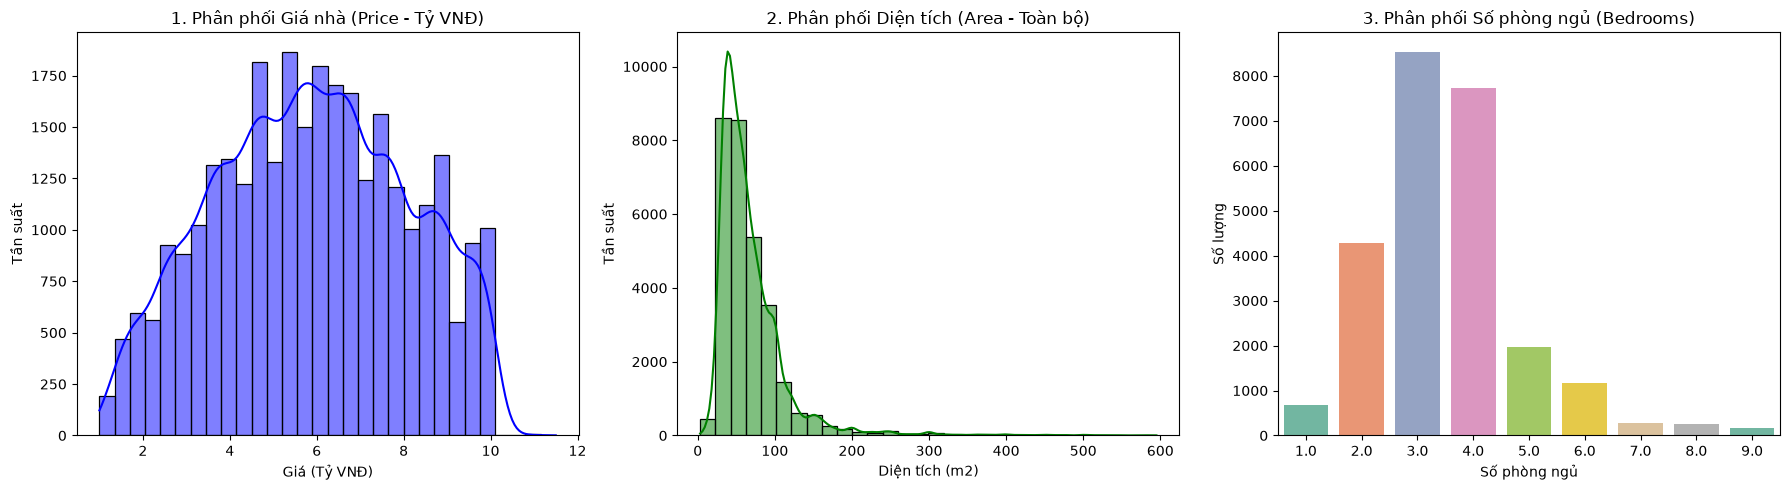

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

# Biểu đồ 1: Phân phối Giá nhà (Price - Target)
plt.subplot(1, 3, 1)
sns.histplot(df_clean["Price"], kde=True, color="blue", bins=30)
plt.title("1. Phân phối Giá nhà (Price - Tỷ VNĐ)")
plt.xlabel("Giá (Tỷ VNĐ)")
plt.ylabel("Tần suất")

# Biểu đồ 2: Phân phối Diện tích (Area - Toàn bộ dữ liệu gốc)
plt.subplot(1, 3, 2)
sns.histplot(df_clean["Area"], kde=True, color="green", bins=30)
plt.title("2. Phân phối Diện tích (Area - Toàn bộ)")
plt.xlabel("Diện tích (m2)")
plt.ylabel("Tần suất")

# Biểu đồ 3: Phân phối Số phòng ngủ (Bedrooms)
plt.subplot(1, 3, 3)
sns.countplot(data=df_clean, x="Bedrooms", palette="Set2")
plt.title("3. Phân phối Số phòng ngủ (Bedrooms)")
plt.xlabel("Số phòng ngủ")
plt.ylabel("Số lượng")

plt.tight_layout()
plt.show()

In [5]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

# Định nghĩa 5 mô hình
models = {
    "Linear Regression": Pipeline(
        [("prep", preprocessor), ("reg", LinearRegression())]
    ),
    "Ridge Regression": Pipeline(
        [("prep", preprocessor), ("reg", Ridge(alpha=1.0))]
    ),
    "Decision Tree": Pipeline(
        [
            ("prep", preprocessor),
            ("reg", DecisionTreeRegressor(max_depth=10, random_state=42)),
        ]
    ),
    "Random Forest": Pipeline(
        [
            ("prep", preprocessor),
            (
                "reg",
                RandomForestRegressor(
                    n_estimators=100, max_depth=12, random_state=42, n_jobs=-1
                ),
            ),
        ]
    ),
    "Gradient Boosting": Pipeline(
        [
            ("prep", preprocessor),
            (
                "reg",
                GradientBoostingRegressor(
                    n_estimators=100, max_depth=5, random_state=42
                ),
            ),
        ]
    ),
}

# Huấn luyện tất cả các mô hình
trained_models = {}
for name, model in models.items():
    print(f"Đang huấn luyện {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
print("Hoàn thành huấn luyện 5 mô hình!")

Đang huấn luyện Linear Regression...
Đang huấn luyện Ridge Regression...
Đang huấn luyện Decision Tree...
Đang huấn luyện Random Forest...
Đang huấn luyện Gradient Boosting...
Hoàn thành huấn luyện 5 mô hình!


In [6]:
import numpy as np
import pickle
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

results = []

# 1. Đo lường 5 độ đo trên tập Test
for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    results.append(
        {
            "Model": name,
            "MAE (Tỷ)": round(mean_absolute_error(y_test, y_pred), 4),
            "MSE": round(mean_squared_error(y_test, y_pred), 4),
            "RMSE (Tỷ)": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
            "MAPE (%)": round(
                mean_absolute_percentage_error(y_test, y_pred) * 100, 2
            ),
            "R2 Score": round(r2_score(y_test, y_pred), 4),
        }
    )

df_results = pd.DataFrame(results)

# 2. Xét các tiêu chí
best_in_metric = {
    "MAE (Tỷ)": df_results.loc[df_results["MAE (Tỷ)"].idxmin()][
        "Model"
    ],
    "MSE": df_results.loc[df_results["MSE"].idxmin()]["Model"],
    "RMSE (Tỷ)": df_results.loc[df_results["RMSE (Tỷ)"].idxmin()][
        "Model"
    ],
    "MAPE (%)": df_results.loc[df_results["MAPE (%)"].idxmin()][
        "Model"
    ],
    "R2 Score": df_results.loc[df_results["R2 Score"].idxmax()][
        "Model"
    ],
}

# 3. Đếm số tiêu chí mỗi mô hình
vote_counts = pd.Series(list(best_in_metric.values())).value_counts()
df_results["Số tiêu chí thắng (/5)"] = (
    df_results["Model"].map(vote_counts).fillna(0).astype(int)
)

# Sắp xếp theo số tiêu chí thắng nhiều nhất
df_results = df_results.sort_values(
    by="Số tiêu chí thắng (/5)", ascending=False
).reset_index(drop=True)

# 4. Hiển thị bảng tổng hợp
print("BẢNG SO SÁNH 5 MÔ HÌNH")
display(df_results)

print("\nCHI TIẾT TỪNG TIÊU CHÍ")
for metric, winner in best_in_metric.items():
    print(f"• {metric}: {winner}")

# 5. Kết luận mô hình tốt nhất
best_model_name = df_results.iloc[0]["Model"]
best_votes = df_results.iloc[0]["Số tiêu chí thắng (/5)"]
best_model = trained_models[best_model_name]

filename = "house_price_model.sav"
with open(filename, "wb") as file:
    pickle.dump(best_model, file)

print(f"{best_model_name} (Đạt {best_votes}/5 tiêu chí xuất sắc nhất)")
print(f"Đã lưu thành công: {filename}")

BẢNG SO SÁNH 5 MÔ HÌNH


,Model,MAE (Tỷ),MSE,RMSE (Tỷ),MAPE (%),R2 Score,Số tiêu chí thắng (/5)
0,Gradient Boosting,1.2656,2.5834,1.6073,27.68,0.4702,3
1,Random Forest,1.2624,2.6068,1.6146,27.56,0.4654,2
2,Linear Regression,1.4501,3.2840,1.8122,32.11,0.3265,0
3,Decision Tree,1.3285,2.9239,1.7099,29.15,0.4003,0
4,Ridge Regression,1.4503,3.2816,1.8115,32.12,0.3270,0



CHI TIẾT TỪNG TIÊU CHÍ
• MAE (Tỷ): Random Forest
• MSE: Gradient Boosting
• RMSE (Tỷ): Gradient Boosting
• MAPE (%): Random Forest
• R2 Score: Gradient Boosting
Gradient Boosting (Đạt 3/5 tiêu chí xuất sắc nhất)
Đã lưu thành công: house_price_model.sav
